# Анализ параметров компьютерных игр интернет-магазина "Стримчик"

## Первичный анализ данных

В нашем распоряжении данные о компьютерных играх интернет-магазина "Стримчик" до 2016 года. Из открытых источников доступны данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation).  Нужно выявить определяющие успешность игры закономерности, что позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании на 2017 г.

Примечание: ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».
Подробнее о системе рейтинга ESRB:
- "EC" ("Early childhood") — "Для детей младшего возраста"
- "E" ("Everyone") — "Для всех"
- "E10+" ("Everyone 10 and older") — "Для всех от 10 лет и старше"
- "T" ("Teen") — "Подросткам"
- "M" ("Mature") — "Для взрослых"
- "AO" ("Adults Only 18+") — "Только для взрослых"

In [1]:
#Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Загружаю данные из csv-файла в датафрейм c помощью библиотеки pandas и сохраняю их в переменную games_df
games_df = pd.read_csv('/datasets/games.csv')

In [3]:
#Вывожу первые 5 строк датафрейма и общую информацию о нем
display(games_df.head(5))
print(games_df.info())

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


 **Вывод:** В файле содержатся данные о 16715 компьютерных играх. Данные включают в себе 11 параметров: название игры (Name); платформа (Platform); год выпуска (Year_Of_Release); жанр игры (Genre); продажи в Северной Америке в миллионах проданных копий (NA_sales); продажи в Европе в миллионах проданных копий (EU_sales); продажи в Японии в миллионах проданных копий (JP_sales); продажи в других странах в миллионах проданных копий (Other_sales); оценка критиков, где максимальная оценка составляет 100 (Critic_Score); оценка пользователей, где максимальная оценка составляет 10 (User_Score); рейтинг от организации ESRB (Rating). Также стоит отметить, что столбцы " Year_of_Release" и "User_Score" имеют неправильный тип данных, дополнительно можно заменить тип данных в столбце "Critic_Score" с float на int для экономии памяти.

## Предобработка данных. 

In [4]:
#Привожу названия столбцов к нижнему регистру
games_df.columns = games_df.columns.str.lower()
games_df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [5]:
#Проверяю наличие пропущенных значений в датафрейме
games_df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

**Вывод:** В 6 столбцах датафрейма имеются пропущенные значения: 
- "name" - 2 пропуска; 
- "year_of_release" - 269 пропусков;
- "genre" - 2 пропуска;
- "critic_score" - 8578 пропусков;
- "user_score" 6701 пропуск;
- "rating" 6766 пропусков.

In [6]:
#Удаляю пропуски в столбцах 'name', 'year_of_release', 'genre'
games_df = games_df.dropna(subset=['name','genre', 'year_of_release']) 
#Изменяю пропуски в столбце 'rating' на 'unknown'
games_df['rating'] = games_df['rating'].fillna('unknown')
#Изменяю тип данных в столбце 'year_of_release' с object на float для последующего удаления десятичной части
games_df['year_of_release'] = games_df['year_of_release'].astype(float)
#Убираю десятичную часть в значениях для года выпуска
games_df['year_of_release'] = games_df['year_of_release'].apply(lambda x: str(int(x)))

**Вывод:** Строчки с пропусками в столбцах 'name', 'genre', 'year_of_release' составляют небольшую часть данных, поэтому были удалены из датафрейма. Пропуски в 'rating' были изменены на 'unknown', так как у них тип данных - object. Также избавились от десятичной части в значениях в столбце 'year_of_release'.

In [7]:
#Изменяю пропуски и значения 'tbd' в столбце 'user_score' на 0 
games_df.loc[games_df['user_score'] == 'tbd', 'user_score'] = 0
games_df['user_score'] = games_df['user_score'].fillna(0)
#Преобразую тип данных в столбце 'user_score' с object на float
games_df['user_score'] = games_df['user_score'].astype(float)
#Изменяю пропуски в столбце 'critic_score' на 0
games_df['critic_score'] = games_df['critic_score'].fillna(0)
#Преобразую тип данных в столбце 'critic_score' с float на int
games_df['critic_score'] = games_df['critic_score'].astype(int)

**Вывод:** Абреввиатура 'tbd' в столбце 'user_score' означает, что оценка будет определена позднее. Эти значения вместе с пропусками в данном столбце были изменены на 0. Пропуски в столбце 'critic_score' также были заполнены нулями, а тип данных изменен с float на int для экономии памяти.

In [8]:
#Проверяю изменились ли типы данных в столбцах
games_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  object 
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     16444 non-null  int64  
 9   user_score       16444 non-null  float64
 10  rating           16444 non-null  object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.5+ MB


**Вывод:** Были успешно изменены типы данных в столбцах 'year_of_release', 'critic_score' и 'user_score'.

In [9]:
#Проверяю наличие пропусков в столбцах
games_df.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

**Вывод:** Пропуски были успешно изменены на соответствующие значения в столбцах 'name', 'year_of_release', 'genre', 'critic_score', 'user_score' И 'rating'.

In [10]:
#Считаю сумммарные продажи во всех регионах и сохраняю результаты в столбец 'total_sales'
games_df['total_sales'] = games_df['na_sales'] + games_df['eu_sales'] + games_df['jp_sales'] + games_df['other_sales']
display(games_df.head(5))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0,0.0,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0,0.0,unknown,31.38


**Общий вывод:** Была проведена предобработка данных, в ходе чего пропуски были изменены на соответствующие значения в столбцах 'name', 'year_of_release', 'genre', 'critic_score', 'user_score' И 'rating', а также были изменены типы данных в столбцах 'year_of_release' и 'user_score'. Кроме того, был добавлен столбец 'total_sales', в котором содержатся значения суммарных продаж во всех регионах.

## Исследовательский анализ данных. 

In [11]:
#Смотрю сколько игр выпускалось в разные годы
games_df['year_of_release'].value_counts().sort_index()

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64

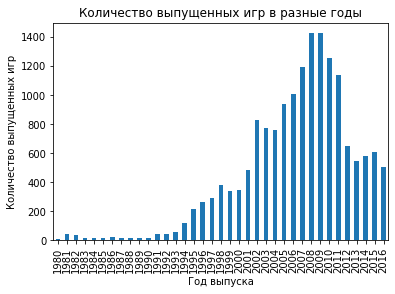

In [12]:
#Строю столбчатую диаграмму для визуализации кол-ва выпущенных игр в разные годы
games_df['year_of_release'].value_counts().sort_index().plot.bar()
plt.title('Количество выпущенных игр в разные годы')
plt.xlabel('Год выпуска')
plt.ylabel('Количество выпущенных игр')
plt.show()

**Вывод:** По данным можно наблюдать, что с 1994 года количество выпущенных игр постепенно росло, достигнув максимума в 2008-2009 годах, после чего последовал спад.

In [13]:
#Считаю суммарные продажи для разных платформ и вывожу результаты в порядке убывания
games_df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

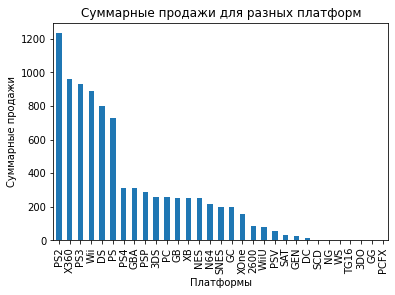

In [14]:
#Строю столбчатую диаграмму для визуализации суммарных продаж для разных платформ
games_df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).plot.bar()
plt.title('Суммарные продажи для разных платформ')
plt.xlabel('Платформы')
plt.ylabel('Суммарные продажи')
plt.show()

**Вывод:** По данным видно, что лидирующие позиции в суммарных продажах занимают платформы 'PS2', 'X360', 'PS3','Wii', 'PS' и 'DS'.

Text(0, 0.5, 'Суммарная продажа')

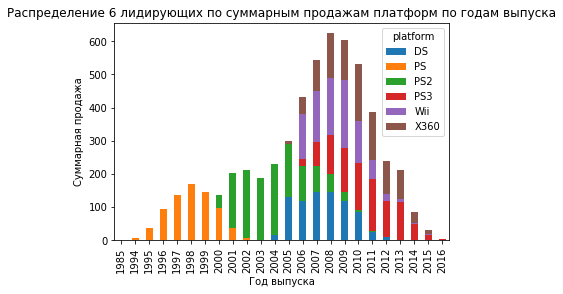

In [15]:
#Выбираю строки с платформами, лидирующими по суммарным продажам, и сохраняю их в переменную top_platforms
top_platforms = games_df.loc[(games_df['platform'] == 'PS2') | (games_df['platform'] == 'X360') | (games_df['platform'] == 'PS3') | (games_df['platform'] == 'Wii') | (games_df['platform'] == 'PS')| (games_df['platform'] == 'DS')] 
#Группирую данные по году выпуска и названию платформы, также считаю суммарную продажу и преобразовываю в датафрейм, сохраняя в переменную top_platforms_df
top_platforms_df = top_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)
#Строю распределение по годам для трех названных платформ
top_platforms_df.plot(kind='bar', stacked=True)
plt.title('Распределение 6 лидирующих по суммарным продажам платформ по годам выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Суммарная продажа')

**Вывод:** По графику видно, что с 1994 по 1999 гг. продавались только платформы 'PS'. С 2000 появились платформы 'PS2', которые окончательно вытеснили 'PS' в 2003 году. С 2004 г. появились платформы 'DS', которые продавались до конца 2012 года. В 2005 году платформы 'PS2' и 'DS' вместе составляли основную сумму продаж, но в это время появилась новая платформа 'X360', которая со временем набирала популярность, достигая наибольших продаж в 2008 году, а затем постепенно теряла свою актуальность, пока не была полностью вытеснена к 2016 году. С 2006 по 2014 гг. на втором месте по популярности после 'X360' находилась 'Wii'. Кроме того, в 2006 году появилась платформа PS3, которая оставалась востребованной до 2016 года, когда все остальные пять платформ были вытеснены с рынка. Таким образом, характерный срок жизни для платформ составляет от 9 до 11 лет.

In [16]:
#Сохраняю данные для 2016 года в переменную games_2016
games_2016 = games_df.loc[games_df['year_of_release'] == '2016']
#Считаю суммарные продажи для платформ в 2016
games_2016.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS4     69.25
XOne    26.15
3DS     15.14
PC       5.25
WiiU     4.60
PSV      4.25
PS3      3.60
X360     1.52
Wii      0.18
Name: total_sales, dtype: float64

In [17]:
#Сохраняю данные для 2015-2016 годов в переменную games_15_16
games_15_16 = games_df.loc[(games_df['year_of_release'] == '2016') | (games_df['year_of_release'] == '2015')]
#Считаю суммарные продажи для платформ в 2015-2016 годах и сохраняю их в переменную total_sales_by_plat
total_sales_by_plat = games_15_16.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(total_sales_by_plat)

platform
PS4     188.15
XOne     86.29
3DS      42.92
WiiU     20.95
PS3      20.42
PC       13.77
X360     13.48
PSV      10.50
Wii       1.32
PSP       0.12
Name: total_sales, dtype: float64


**Вывод:** Данные для 2016 и 2015 годов не сильно разнятся, следовательно можно принять данные за последние 2 года за актуальный период для построения прогноза на 2017 год. По данным актуального периода видно, что на первых позициях по продажам находились платформы 'PS4', 'XOne', '3DS' со значениями 188.01 млн., 85.74 млн., 42.31 млн. соответственно. Наименее продаваемыми оказались платформы 'Wii' и 'PSP' в этих годах. Более того, стоит отметить, что по сравнению с 2015 годом продажи перечисленных платформ падают в 2016 году.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'PS4'),
  Text(1, 0, 'XOne'),
  Text(2, 0, '3DS'),
  Text(3, 0, 'WiiU'),
  Text(4, 0, 'PS3'),
  Text(5, 0, 'X360'),
  Text(6, 0, 'PC'),
  Text(7, 0, 'Wii'),
  Text(8, 0, 'PSV'),
  Text(9, 0, 'PSP')])

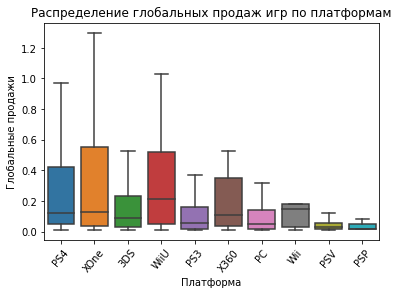

In [18]:
#Строю диаграмму размаха по глобальным продажам игр в разбивке по платформам
sns.boxplot(x='platform', y='total_sales', data=games_15_16, showfliers=False)

plt.title('Распределение глобальных продаж игр по платформам')
plt.xlabel('Платформа')
plt.ylabel('Глобальные продажи')
plt.xticks(rotation=50)

**Вывод:** Из графика можно сделать вывод, что потенциально прибыльными платформами являются 'PS4', 'XOne', '3DS' и 'WiiU'. Платформа 'WiiU' выделяется наибольшей медианой по продажам, в то время как 'PS4' и 'XOne' имеют схожие медианные значения. Медиана по продажам на платформе '3DS' немного ниже, чем у 'PS4' и 'XOne'.

Text(0, 0.5, 'Глобальные продажи')

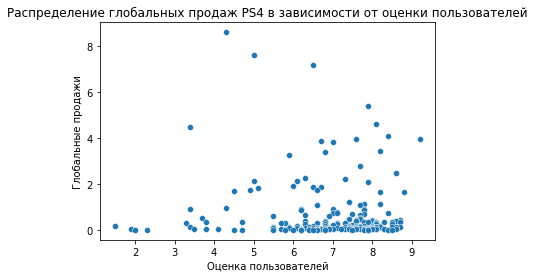

In [19]:
#Смотрю как влияют отзывы пользователей и критиков на продажи внутри одной популярной платформы для 2015-2016 гг
#Сохраняю данные для платформы 'PS4' в переменную ps4_df 
ps4_df = games_15_16.loc[(games_15_16['platform'] == 'PS4') & (games_15_16['user_score'] != 0) & (games_15_16['critic_score'] != 0)] 
#Cтрою диаграмму рассеяния для глобальных продаж в зависимости от оценки пользователей
sns.scatterplot(x='user_score', y='total_sales', data=ps4_df)
plt.title('Распределение глобальных продаж PS4 в зависимости от оценки пользователей')
plt.xlabel('Оценка пользователей')
plt.ylabel('Глобальные продажи')

Text(0, 0.5, 'Глобальные продажи')

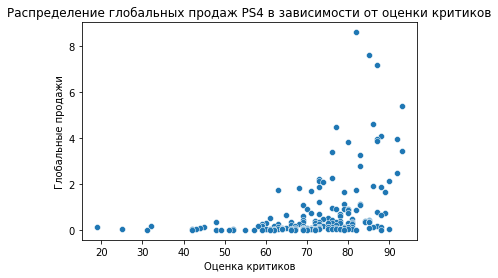

In [20]:
#Cтрою диаграмму рассеяния для глобальных продаж в зависимости от оценки пользователей
sns.scatterplot(x='critic_score', y='total_sales', data=ps4_df)
plt.title('Распределение глобальных продаж PS4 в зависимости от оценки критиков')
plt.xlabel('Оценка критиков')
plt.ylabel('Глобальные продажи')

In [21]:
#Строю матрицу корреляции для выявления корреляции между различными факторами и глобальными продажами 
ps4_df.corr()

,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
na_sales,1.000000,0.612675,0.495716,0.880278,0.405491,-0.030915,0.848279
eu_sales,0.612675,1.000000,0.455742,0.914159,0.309869,-0.091554,0.937074
jp_sales,0.495716,0.455742,1.000000,0.527864,0.366655,0.188618,0.555502
other_sales,0.880278,0.914159,0.527864,1.000000,0.394093,-0.070394,0.997212
critic_score,0.405491,0.309869,0.366655,0.394093,1.000000,0.533330,0.392074
user_score,-0.030915,-0.091554,0.188618,-0.070394,0.533330,1.000000,-0.064368
total_sales,0.848279,0.937074,0.555502,0.997212,0.392074,-0.064368,1.000000


Text(0, 0.5, 'Глобальные продажи')

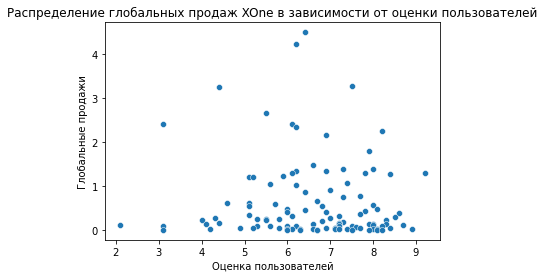

In [22]:
#Сохраняю данные для платформы 'XOne' в переменную xone_df 
xone_df = games_15_16.loc[(games_15_16['platform'] == 'XOne') & (games_15_16['user_score'] != 0) & (games_15_16['critic_score'] != 0)] 
#Cтрою диаграмму рассеяния для глобальных продаж в зависимости от оценки пользователей
sns.scatterplot(x='user_score', y='total_sales', data=xone_df)
plt.title('Распределение глобальных продаж XOne в зависимости от оценки пользователей')
plt.xlabel('Оценка пользователей')
plt.ylabel('Глобальные продажи')

Text(0, 0.5, 'Глобальные продажи')

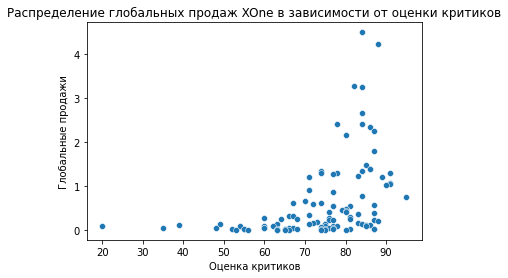

In [23]:
#Cтрою диаграмму рассеяния для глобальных продаж в зависимости от оценки пользователей
sns.scatterplot(x='critic_score', y='total_sales', data=xone_df)
plt.title('Распределение глобальных продаж XOne в зависимости от оценки критиков')
plt.xlabel('Оценка критиков')
plt.ylabel('Глобальные продажи')

In [24]:
#Строю матрицу корреляции для выявления корреляции между различными факторами и глобальными продажами 
xone_df.corr()

,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
na_sales,1.000000,0.553023,0.398726,0.975378,0.397656,-0.040900,0.935263
eu_sales,0.553023,1.000000,0.407230,0.720626,0.338325,-0.095630,0.812086
jp_sales,0.398726,0.407230,1.000000,0.434371,0.203343,0.101729,0.456305
other_sales,0.975378,0.720626,0.434371,1.000000,0.421362,-0.060920,0.989316
critic_score,0.397656,0.338325,0.203343,0.421362,1.000000,0.459443,0.422519
user_score,-0.040900,-0.095630,0.101729,-0.060920,0.459443,1.000000,-0.068684
total_sales,0.935263,0.812086,0.456305,0.989316,0.422519,-0.068684,1.000000


Text(0, 0.5, 'Глобальные продажи')

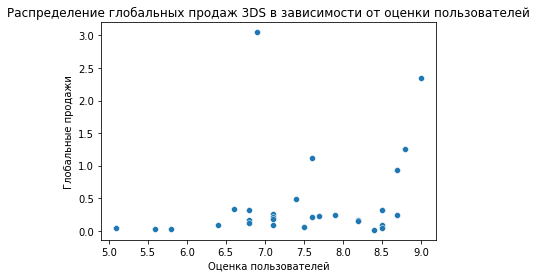

In [25]:
#Сохраняю данные для платформы '3DS' в переменную 3ds_df 
threeds_df = games_15_16.loc[(games_15_16['platform'] == '3DS') & (games_15_16['user_score'] != 0) & (games_15_16['critic_score'] != 0)] 
#Cтрою диаграмму рассеяния для глобальных продаж в зависимости от оценки пользователей
sns.scatterplot(x='user_score', y='total_sales', data=threeds_df)
plt.title('Распределение глобальных продаж 3DS в зависимости от оценки пользователей')
plt.xlabel('Оценка пользователей')
plt.ylabel('Глобальные продажи')

Text(0, 0.5, 'Глобальные продажи')

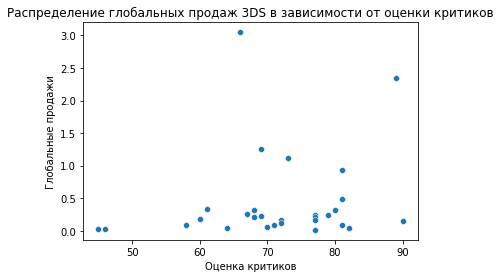

In [26]:
#Cтрою диаграмму рассеяния для глобальных продаж в зависимости от оценки пользователей
sns.scatterplot(x='critic_score', y='total_sales', data=threeds_df)
plt.title('Распределение глобальных продаж 3DS в зависимости от оценки критиков')
plt.xlabel('Оценка критиков')
plt.ylabel('Глобальные продажи')

In [27]:
#Строю матрицу корреляции для выявления корреляции между различными факторами и глобальными продажами 
threeds_df.corr()

,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
na_sales,1.000000,0.761501,0.582850,0.977203,0.316251,0.388573,0.859182
eu_sales,0.761501,1.000000,0.917793,0.874150,0.080819,0.137705,0.973867
jp_sales,0.582850,0.917793,1.000000,0.719799,0.074179,0.117738,0.909739
other_sales,0.977203,0.874150,0.719799,1.000000,0.269639,0.334355,0.940142
critic_score,0.316251,0.080819,0.074179,0.269639,1.000000,0.791853,0.177575
user_score,0.388573,0.137705,0.117738,0.334355,0.791853,1.000000,0.240477
total_sales,0.859182,0.973867,0.909739,0.940142,0.177575,0.240477,1.000000


**Вывод:** На диаграммах рассеяния для двух самых продаваемых платформ в 2015-2016 годах — 'PS4' и 'XOne' — можно наблюдать умеренную положительную корреляцию между суммарными продажами и оценками критиков (0.39 и 0.42 соответственно). Для платформы '3DS' эта корреляция очень слабая (0.18), что свидетельствует о почти отсутствующей связи между этими переменными. Интересно, что на платформах 'PS4' и 'XOne' не наблюдается корреляции между суммарными продажами и оценками пользователей, в то время как на платформе '3DS' существует очень слабая положительная корреляция (0.24) между этими параметрами.

Text(0, 0.5, 'Глобальные продажи')

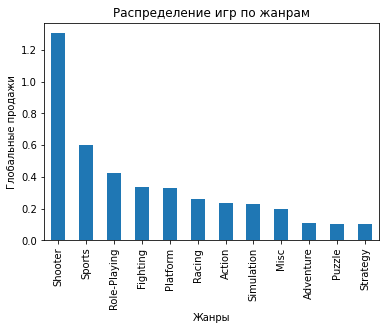

In [28]:
#Построила общее распределение игр по жанрам
games_15_16.groupby('genre')['total_sales'].mean().sort_values(ascending=False).plot.bar();
plt.title('Распределение игр по жанрам')
plt.xlabel('Жанры')
plt.ylabel('Глобальные продажи')

**Вывод:** По таблице видно, что самым прибыльным жанром является 'Shooter'. Далее идут 'Sports' и 'Role-Playing', однако стоит отметить, что последние по средним показателям продаж сильно уступали первому (примерно в 2 раза меньше).

**Общий вывод:** Был проведен тщательный исследовательский анализ, в ходе которого было выявлено, что платформы 'PS2', 'X360', 'PS3' лидируют в суммарных продажах, был исследован характер изменения продаж по платформам на протяжении всего периода. Для дальнейшего построения прогноза на 2017 год были взяты данные для 2015-2016 годов, которые выявили, что в этих годах наибольшими глобальными продажами обладали платформы 'PS4', 'XOne', '3DS', также стоит отметить слабую корреляцию между суммарными продажами и оценкой критиков для платформы 'PS4'. По популярности и по глобальным продажам на первых позициях были жанры 'Action', 'Shooter', 'Sport', а на последних - 'Puzzle' и 'Strategy'.

## Характеристика портрета пользователя каждого региона.

In [29]:
#Вывожу суммарные продажи в зависимости от региона для всех платформ
print(games_15_16.groupby('platform')['na_sales'].sum().sort_values(ascending=False))
print(games_15_16.groupby('platform')['eu_sales'].sum().sort_values(ascending=False))
games_15_16.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)

platform
PS4     63.86
XOne    50.30
3DS     10.31
WiiU     8.86
X360     8.05
PS3      5.66
PC       3.72
PSV      0.54
Wii      0.49
PSP      0.00
Name: na_sales, dtype: float64
platform
PS4     83.54
XOne    28.10
PC       9.10
3DS      7.39
PS3      7.30
WiiU     6.49
X360     4.21
PSV      1.08
Wii      0.73
PSP      0.00
Name: eu_sales, dtype: float64


platform
3DS     23.55
PS4     12.05
PSV      8.41
PS3      4.97
WiiU     4.12
XOne     0.18
PSP      0.12
PC       0.00
Wii      0.00
X360     0.00
Name: jp_sales, dtype: float64

<AxesSubplot:title={'center':'Суммарные продажи в Северной Америке'}, xlabel='Платформа', ylabel='Суммарные продажи'>

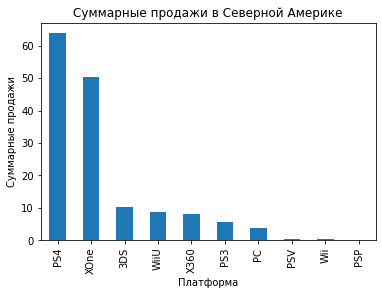

In [30]:
#Вывожу суммарные продажи в Северной Америке
games_15_16.groupby('platform')['na_sales'].sum().sort_values(ascending=False).plot.bar(title='Суммарные продажи в Северной Америке', xlabel='Платформа', ylabel='Суммарные продажи')

<AxesSubplot:title={'center':'Суммарные продажи в Европе'}, xlabel='Платформа', ylabel='Суммарные продажи'>

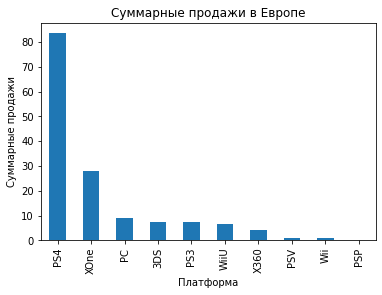

In [31]:
#Вывожу суммарные продажи в Европе
games_15_16.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).plot.bar(title='Суммарные продажи в Европе', xlabel='Платформа', ylabel='Суммарные продажи')

<AxesSubplot:title={'center':'Суммарные продажи в Японии'}, xlabel='Платформа', ylabel='Суммарные продажи'>

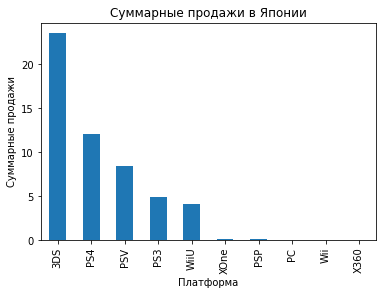

In [32]:
#Вывожу суммарные продажи в Японии
games_15_16.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).plot.bar(title='Суммарные продажи в Японии', xlabel='Платформа', ylabel='Суммарные продажи')

**Вывод:** 'PS4' была самой популярной платформой, которая входила в топ-5 всех трех регионов. При этом самая высокая продажа 'PS4' отмечалась в Европе (83.54 млн.), на втором месте - Северная Америка (63.74 млн.), намного меньше в Японии (12.05 млн.). По данным видно, что в Северной Америке и Европе рынок больше чем в Японии, так большая доля продаж находилась именно в этих регионах. На второй позиции по продажам в Северной Америке и Европе оказалась платформа 'XOne' cо значениями 49.95 млн. и 27.94 млн. соответственно, однако в Японии она занимает лишь шестую позицию (0.18 млн.). В Японии самой популярной платформой оказалась '3DS' (23.50 млн.), которая занимает третье место по продажам в Северной Америке (10.12 млн.) и четвертое - в Европе (7.05 млн.). Довольно популярной также оказалась платформа 'WiiU', которая находится входит в топ 5 для Северной Америки и Японии со значениями 8.68 млн. и 4.12 млн., но находится на шестом месте по продажам в Европе (6.33 млн.). Похожую ситуацию видим у платформы 'PS3', которая находится на пятом месте в Европе (6.85 млн.) и четвертом в Японии (4.69 млн.), но на шестом в Северной Америке (5.53 млн.). 

In [33]:
#Вывожу суммарные продажи в зависимости от жанра для всех платформ
print(games_15_16.groupby('genre')['na_sales'].sum().sort_values(ascending=False))
print(games_15_16.groupby('genre')['eu_sales'].sum().sort_values(ascending=False))
games_15_16.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)

genre
Shooter         48.18
Action          33.68
Sports          26.31
Role-Playing    19.82
Misc             5.58
Fighting         5.54
Adventure        3.84
Platform         3.78
Racing           2.82
Simulation       1.36
Strategy         0.82
Puzzle           0.06
Name: na_sales, dtype: float64
genre
Shooter         40.28
Action          34.82
Sports          27.82
Role-Playing    17.21
Racing           6.52
Adventure        4.67
Misc             4.26
Simulation       3.74
Fighting         3.72
Platform         3.20
Strategy         1.57
Puzzle           0.13
Name: eu_sales, dtype: float64


genre
Action          23.05
Role-Playing    13.41
Shooter          3.79
Misc             3.19
Adventure        2.22
Simulation       1.93
Sports           1.65
Fighting         1.54
Platform         1.42
Puzzle           0.52
Strategy         0.39
Racing           0.29
Name: jp_sales, dtype: float64

**Вывод:** Самыми популярными жанрами в трех регионах оказались 'Shooter', 'Action', 'Role-Playing'. 'Shooter' занимал первое место по продажам в Северной Америке и Европе со значениями 48.07 млн. и 40.20 млн. соответственно, но только третье место в Японии с сильно меньшим кол-вом проданных копий (3.79 млн.). Cамым популярным жанром в Японии оказался 'Action' c 22.67 млн., который занимает вторую позицию в Северной Америке и Европе со значениями 33.30 млн. и 34.14 млн. соответственно. На втором месте по популярности в Японии оказался 'Role-Playing' (13.41 млн.), занимающий вторую позицию в Северной Америке и Европе со значениями 19.82 млн. и 17.21 млн. соответственно. Стоит также отметить, что в топе-4 для Северной Америки и Европы находятся одни и те же жанры ('Shooter', 'Action','Sports', 'Role-Playing'), занимающие одинаковые позиции со схожим кол-вом продаж. Однако пятое место по продажам в Северной Америке находится 'Fighting' (5.52 млн.), а в Европе - 'Racing' (6.5 млн.). Для Северной Америки и Европы довольно популярным жанром (3-е место) оказался 'Sport' со значениями 26.21 млн. и 27.58 млн. соответственно, в Японии однако он занимал седьмое место (1.65 млн.).

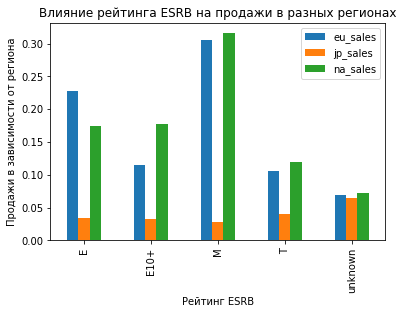

In [34]:
#Строю сводную таблицу для выявления зависимости между рейтингом от организации ESRB и продажами в разных регионах
regions_table = games_15_16.pivot_table(index='rating', values=['na_sales','eu_sales','jp_sales'])
#Cтрою столбчатую диаграмму зависимости продаж в разных регионах от рейтинга организации ESRB
regions_table.plot.bar()
plt.title('Влияние рейтинга ESRB на продажи в разных регионах')
plt.xlabel('Рейтинг ESRB')
plt.ylabel('Продажи в зависимости от региона')
plt.show()

**Вывод:** По графику видно, что рейтинг ESRB похожим образом влияет на продажи в Европе и Северной Америке, однако совсем не имеет влияния на продажи в Японии. Можно отметить, что в Европе и Северной Америке наибольшие продажи у игр с рейтингом 'M', наименьшие - с рейтингом 'T'. Также можно заметить, что в Северной Америке охотнее покупают игры с рейтингом 'E10+' по сравнению с Европой. Обратную ситуацию можно увидеть у игр с рейтингом 'E'.

**Общий вывод:** На этом этапе были определены портреты пользователей каждого региона. Пользователи Северной Америки и Европы имеют схожие предпочтения по всем параметрам, в особенности по жанрам игр. Также похоже, что рейтинг ESRB похожим образом влияет на продажи в этих регионах, что не было отмечено для Японии. Возможно это в комбинации с большим кол-вом пропуском в столбце 'rating' объясняется тем, что в Японии применяется другая рейтинговая система.

## Проверка гипотез.

5.1 Проверка гипотезы о том, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые. \
Нулевая гипотеза: Cредние пользовательские рейтинги платформ Xbox One и PC одинаковые. \
Альтернативная: Cредние пользовательские рейтинги платформ Xbox One и PC разные.

In [35]:
xbox_data = games_15_16.loc[(games_15_16['platform'] == 'XOne') & (games_15_16['user_score'] != 0)]['user_score'].dropna()
pc_data =  games_15_16.loc[(games_15_16['platform'] == 'PC') & (games_15_16['user_score'] != 0)]['user_score'].dropna()

alpha=0.05

results = st.ttest_ind(xbox_data, pc_data)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 

p-значение: 0.2778542084733835
Не отвергаем нулевую гипотезу


**Вывод:** Cредние пользовательские рейтинги платформ Xbox One и PC одинаковые. Был выбран метод st.ttest_ind для проверки гипотезы, так как проверяем гипотезу о равенстве средних двух генеральных совокупностей.

5.2 Проверка гипотезы о том, что средние пользовательские рейтинги жанров Action и Sports разные. \
Нулевая гипотеза: Cредние пользовательские рейтинги жанров Action и Sports одинаковые. \
Альтернативная: Cредние пользовательские рейтинги жанров Action и Sports разные.

In [36]:
action_data = games_15_16.loc[(games_15_16['genre'] == 'Action') & (games_15_16['user_score'] != 0)]['user_score'].dropna()
sports_data = games_15_16.loc[(games_15_16['genre'] == 'Sports') & (games_15_16['user_score'] != 0)]['user_score'].dropna()

alpha = 0.05

results = st.ttest_ind(action_data, sports_data)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 

p-значение: 1.0012846807938657e-13
Отвергаем нулевую гипотезу


**Вывод:** Cредние пользовательские рейтинги жанров Action и Sports разные. Метод для проверки данной гипотезы такой же по той же причине, что и в предыдущем задании.

**Итоговый вывод:** В результате работы была проведена предобработка данных, выявлены лидеры по продажам платформ ('PS2', 'X360', 'PS3') и жанров ('Action', 'Shooter', 'Sport'). Для 2015-2016 годов наибольшими продажами обладали платформы 'PS4', 'XOne', '3DS', а также была выявлена умеренная корреляция между оценками критиков и продажами на 'PS4'. Также определены схожие предпочтения пользователей в Северной Америке и Европе, в отличие от Японии.

Для следующего года рекомендуется продолжить фокусироваться на платформах 'PS4', 'XOne' и '3DS', а также развивать игры для новых платформ. Важно ориентироваться на популярные жанры, такие как 'Action', 'Shooter' и 'Sport', а для 'Puzzle' и 'Strategy' возможно стоит пересмотреть маркетинговую стратегию или концепции игр. Необходимо учитывать влияние рейтинга ESRB на продажи в Северной Америке и Европе, а также продолжать отслеживать отзывы пользователей и критиков. 